In [ ]:
from torchvision import transforms, datasets
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader

import torch
import torch.nn.functional as F

from PIL import Image

from fathomnet.api import images
import requests, os

In [ ]:
from transformers import ViTModel, ViTImageProcessor
model = ViTModel.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

/Users/evankaiden/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
model.eval()

print("Model Loaded")

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
classes = ["jelly", "squid", "crab", "shark"]

def load_class(class_name, max_images=30):
    os.makedirs(f"../data/{class_name}", exist_ok=True)
    recs = images.find_by_concept(class_name)[:max_images]

    for i, r in enumerate(recs):
        url = r.url
        open(f"../data/{class_name}/{i:03d}.jpg","wb").write(requests.get(url, timeout=30).content)

for cls in classes:
    load_class(cls)

print("Data Loaded")

In [195]:
def undo_normalization(img, mean, std):
    mean = torch.tensor(mean).view(1,1,3)
    std = torch.tensor(std).view(1,1,3)
    return img * std + mean

In [196]:
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

dataset = datasets.ImageFolder(root='../data', transform=transform)
data_loader = DataLoader(dataset, batch_size=8, shuffle=True)

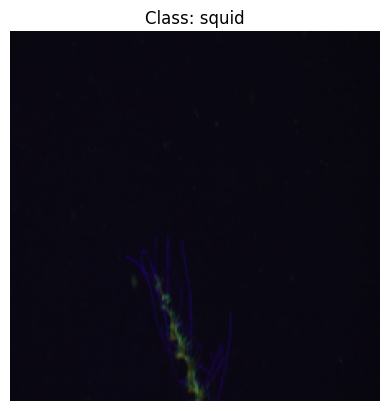

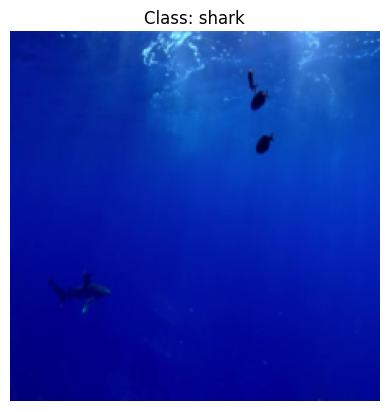

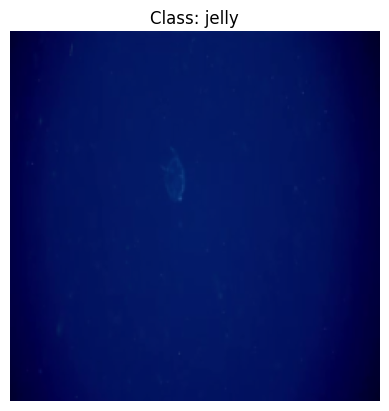

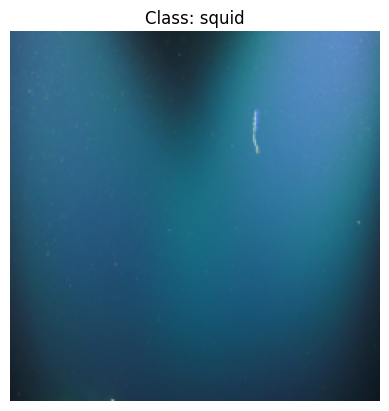

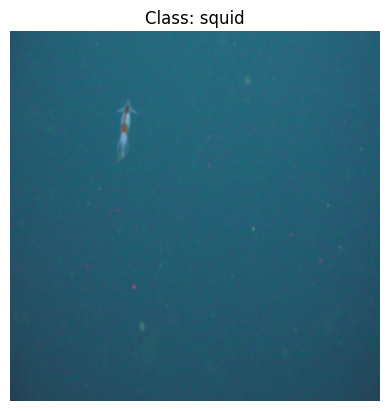

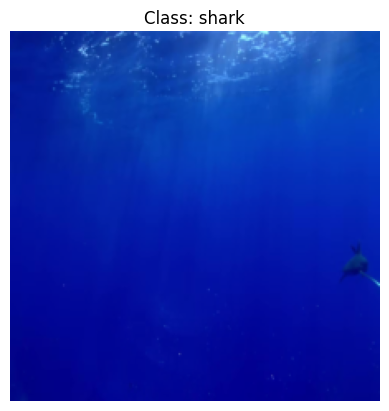

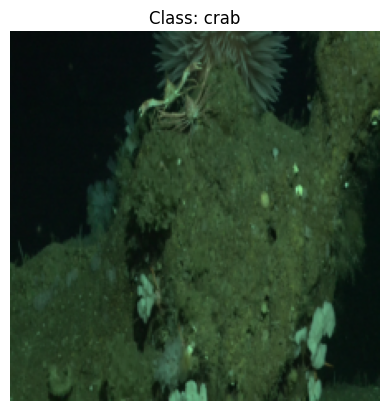

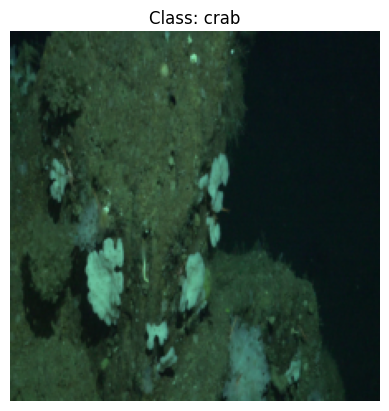

In [197]:
import matplotlib.pyplot as plt
imgs, cls = next(iter(data_loader))
classes = ["crab", "jelly", "shark", "squid"]
for i in range(imgs.size(0)):
    img = imgs[i].permute(1, 2, 0)  
    img = undo_normalization(img, mean, std)
    img = img.clamp(0, 1)            

    plt.imshow(img)
    plt.title(f"Class: {classes[cls[i].item()]}")
    plt.axis("off")
    plt.show(block=False)
    plt.close()

In [198]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.reshape_transforms import vit_reshape_transform

import numpy as np

In [236]:
def get_cam(x: np.array):
    """
    @param x : is a numpy array of shape (H, W, 3)
    """

    x = Image.fromarray((x * 255).astype(np.uint8))

    inputs = processor(images=x, return_tensors='pt')
    output = model(**inputs)

    attn = output.attentions[-1]
    attn = attn.mean(dim=1)
    cls_to_patch = attn[0, 0, 1:]
    num_patches = cls_to_patch.shape[0]
    h_p = w_p = int(np.sqrt(num_patches))
    cam = cls_to_patch.view(1, 1, h_p, w_p)  
    H, W = inputs["pixel_values"].shape[-2:]             
    cam = F.interpolate(cam, size=(H, W), mode="bilinear", align_corners=False)[0, 0]
    cam = cam.clamp(min=0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
    cam_np = cam.detach().cpu().numpy()
    pv = inputs["pixel_values"][0]                       
    mean = torch.tensor(processor.image_mean).view(3,1,1)
    std  = torch.tensor(processor.image_std).view(3,1,1)
    vis = (pv * std + mean).clamp(0,1).permute(1,2,0).cpu().numpy()  

    return vis, cam_np
    

/var/folders/34/f8jr6fln7zng6w9pt5blm15w0000gn/T/ipykernel_64447/4192428594.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean).view(1,1,3)
/var/folders/34/f8jr6fln7zng6w9pt5blm15w0000gn/T/ipykernel_64447/4192428594.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(std).view(1,1,3)


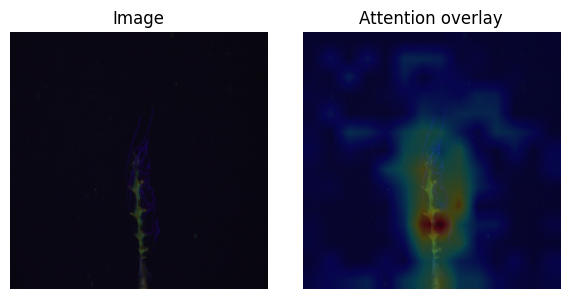

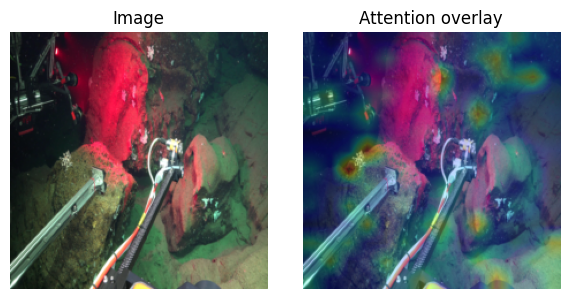

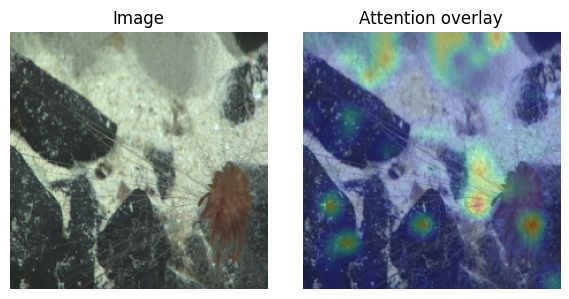

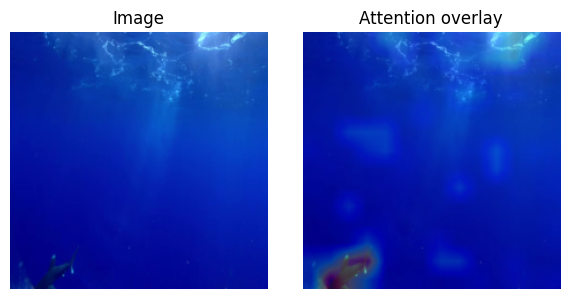

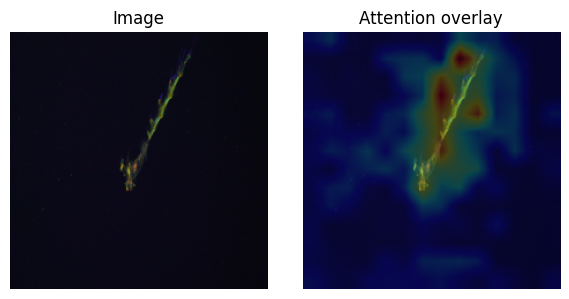

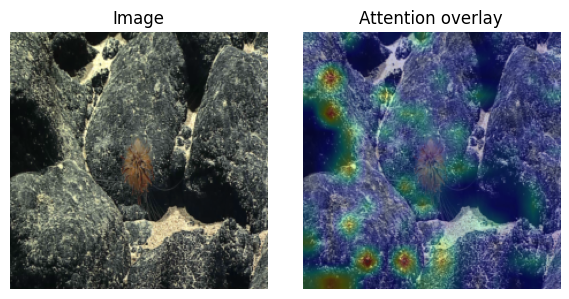

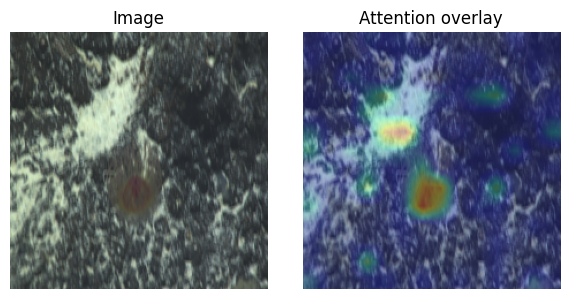

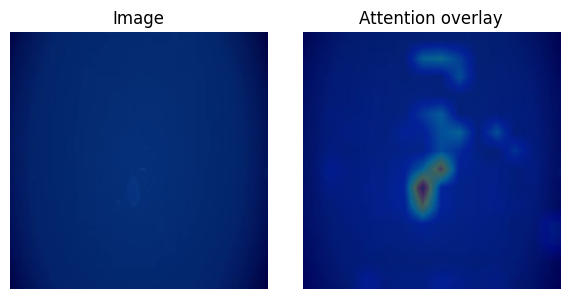

In [247]:
for i in range(imgs.size(0)):
    img_tensor = imgs[i, :, :, :].permute(1,2,0)
    img_np = np.array(img_tensor)
    _, cam_np = get_cam(img_np)

    img = undo_normalization(img_tensor, mean, std)

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.imshow(cam_np, cmap="jet", alpha=0.25)
    plt.title("Attention overlay")
    plt.axis("off")
    plt.tight_layout()
    plt.show(block=False)